In [94]:
import numpy as np
from numpy.linalg import norm
import math, random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import initializers
import time

In [95]:
#spatial funcs for WoS

def closestPoint(v, s):
    u = s[1] - s[0]
    rate = max(0, min(u.dot(v - s[0])/u.dot(u), 1))
    return (s[0] + rate*(s[1] - s[0]))

def shortestDistance(v, segments):
    r = float("inf")
    for s in segments:
        u = closestPoint(v, s)
        if norm(v - u) < r:
            r = norm(v - u)
    return r

In [96]:
def pathGenerator(v, segments, g, eps = 0.001, maxSteps = 25, maxR = 10): 
    x0 = v
    path = []
    for step in range(0, maxSteps): 
        path.append(x0)
        r = min([shortestDistance(x0, segments), maxR])
        if r < eps: 
            return path, g(x0)
        theta = random.uniform(0, 2*math.pi)
        x0 = x0 + np.array([r * math.cos(theta), r * math.sin(theta)])
        
    #resample the path if length 0!!
    
    #return pathGenerator(v, segments, g)
    return [], 0

In [97]:
# set up the problem
segments = [np.array([[-1, -1], [-1, 1]]), np.array([[-1, -1], [1, -1]]), np.array([[1, -1], [1, 0]]), np.array([[-1, 1], [0, 1]]), np.array([[0, 1], [0, 0]]), np.array([[1, 0], [0, 0]])]

#v = np.array([0, 0])
def boundary(v):
    if v[0] >= -0.001 and v[1] >= -0.001:
        return 1
    else:
        return 0

In [98]:
tic = time.perf_counter()#timer
#####evenly distributed start places
#target = []
#width = range(1, 200)
#height = range(1, 200)
#for i in width:
#    for j in height:
#        target.append(np.array([i/100 - 1, j/100 - 1]))
        
#target = np.tile(target_core, [100, 1])
#print(target.shape)

#print(len(target))

###### pure random start places
#target = np.random.rand(40000, 2)
#target = 2* target - 1

#####QMC start places
import scipy.stats as stats
qmcGenerator = stats.qmc.Sobol(d=2)
target = qmcGenerator.random(n=100000)
target = 2* target - 1
target = target[(target[:,0] <= 0) | (target[:,1] <= 0)]
print(target.shape)

#####Single start place at center
#target = np.zeros((40000, 2))


(75000, 2)


In [99]:
paths = []
boundaries = []
maxPath = 0;
for v in target:
    p, b = pathGenerator(v, segments, boundary)
    if len(p) != 0:
        paths.append(p)
        boundaries.append(b)
        if len(p) > maxPath:
            maxPath = len(p)


In [100]:
paths1 = np.zeros((len(paths), maxPath, 2))
for i in range(len(paths)):
    path = paths[i]
    npath = np.array(path)
    if len(path) < maxPath:
        npath = np.concatenate((npath, np.ones((maxPath - len(path), 2)) * np.array(path[len(path) - 1])))

    paths1[i] = npath

print("Total path amount: ")
print(paths1.shape)
tac = time.perf_counter()
print("WoSNN sample time: " + str(tac - tic))

Total path amount: 
(72160, 25, 2)
WoSNN sample time: 22.1554074579999


In [101]:
paths1 = paths1.reshape(-1, maxPath, 2).astype("float32")
boundary1 = np.array(boundaries).astype("float32")

In [102]:
class NN(keras.Model):
    def __init__(self, units):
        super(NN, self).__init__()
        self.layer1 = keras.layers.Dense(units[0])
        self.layer2 = keras.layers.Dense(units[1])
        self.layer3 = keras.layers.Dense(units[2])
        self.outputs = layers.Dense(3)

    def call(self, input_tensor, training):
        x = self.layer1(input_tensor)
        x = tf.nn.relu(x)
        x = self.layer2(x)
        x = tf.nn.relu(x)
        x = self.layer3(x)
        x = tf.nn.relu(x)
        x = self.outputs(x)
        #print(x.shape)
        return x

In [103]:
class Ysolver(keras.Model):
    # set y as a trainable variable, initialized randomly
    def __init__(self, layer):
        super(Ysolver, self).__init__()
        self.model = NN(layer)

        #self.y = tf.Variable(np.random.uniform(low=-1, high=1, size=[1, 1]),trainable = True, dtype ="float32")

    def call(self, path, training, batch):
        #print(path.shape)
        y_pred = self.model(path[:, 0], training)[:, 0]
        #print(y_pred.shape)
        for i in range(len(path[0]) - 1): ###input path should be (-1, 2) shaped nparray, no len()
            #y = self.Ymodel(path[:, i], training)
            #print(y.shape)
            #z_input = tf.concat([path[:, i],y], 1)
            z = self.model(path[:, i], training)[:, 1:3] #obtain gradients for steps
            diff = path[:, i + 1] - path[:, i]
            #print(diff.shape)
            add = z[:, 0]*diff[:, 0] + z[:, 1]*diff[:, 1] #accumulating
            #print(add.shape)
            y_pred += add

        return y_pred

In [104]:
class NNsolver(keras.Model):
    def __init__(self, paths, boundary):
        super(NNsolver, self).__init__()
        self.paths = paths
        self.boundary = np.array(boundary)
        self.model = Ysolver([32, 64, 128])
        self.optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=3e-4 , epsilon=1e-8)

    def loss_fn(self, y_pred, y):
        delta = y_pred - y
        loss = tf.reduce_mean(tf.square(delta))
        return loss

    def train_step(self, cur_path, training, batch_size):           
        return self.model(cur_path, training, batch_size)

    def train(self, batch_size): 
        training_history = []
        for i in range((len(self.paths) - 1)//batch_size + 1):
            batch = batch_size
            if (i + 1) * batch_size > len(paths):
                batch = len(paths) - i * batch_size
            cur_path = self.paths[i*batch_size: i*batch_size + batch]
            cur_bound = self.boundary[i*batch_size: i*batch_size + batch]
                
            with tf.GradientTape() as tape:
                y_pred = self.train_step(cur_path, training = True, batch_size=batch)
                loss = self.loss_fn(y_pred, cur_bound)

            training_vars = self.model.trainable_variables 
            grad = tape.gradient(loss, training_vars)
            #print(grad)
            #print("----------------------------------------------------")
            self.optimizer.apply_gradients(zip(grad, training_vars))
            #print(self.model.Ymodel.trainable_variables)
            training_history.append(loss)

        return training_history

    def train_epoch(self, epoch, batch_size):
        for i in range(epoch):
            cur_history = self.train(batch_size)
            print("epoch: " + str(i) + " loss: "+ str(np.mean(np.array(cur_history))))


In [105]:
tic = time.perf_counter()
training = NNsolver(paths1, boundary1)
training.train_epoch(150, 2048)
tac = time.perf_counter()
print("WoSNN training time: " + str(tac - tic))

epoch: 0 loss: 0.2441042
epoch: 1 loss: 0.15970251
epoch: 2 loss: 0.09948979
epoch: 3 loss: 0.058171637
epoch: 4 loss: 0.04315373
epoch: 5 loss: 0.03654688
epoch: 6 loss: 0.03197502
epoch: 7 loss: 0.028382957
epoch: 8 loss: 0.025429364
epoch: 9 loss: 0.02300779
epoch: 10 loss: 0.021158336
epoch: 11 loss: 0.019744204
epoch: 12 loss: 0.018617958
epoch: 13 loss: 0.017708061
epoch: 14 loss: 0.016977634
epoch: 15 loss: 0.016394224
epoch: 16 loss: 0.015929287
epoch: 17 loss: 0.015549417
epoch: 18 loss: 0.015228275
epoch: 19 loss: 0.01495914
epoch: 20 loss: 0.01472666
epoch: 21 loss: 0.014526011
epoch: 22 loss: 0.014347202
epoch: 23 loss: 0.014185609
epoch: 24 loss: 0.014040207
epoch: 25 loss: 0.013909206
epoch: 26 loss: 0.013787844
epoch: 27 loss: 0.013676258
epoch: 28 loss: 0.013574869
epoch: 29 loss: 0.013480373
epoch: 30 loss: 0.0133911595
epoch: 31 loss: 0.013307729
epoch: 32 loss: 0.013228903
epoch: 33 loss: 0.013153865
epoch: 34 loss: 0.0130844265
epoch: 35 loss: 0.013016781
epoch: 36 

In [106]:
print(training.model.model(np.array([0.5, 0.5]).reshape([1, 2]).astype("float32")))

tf.Tensor([[1.8754567 1.1381822 3.0894797]], shape=(1, 3), dtype=float32)


In [128]:
tic = time.perf_counter()
width = range(101)
height = range(101)

X = []
Y = []
Z = []
for i in width:
    for j in height:
        X.append(i/50 - 1)
        Y.append(j/50 - 1)
        if (i/50 - 1) <= 0 or (j/50 - 1) <= 0:
            Z.append(training.model.model(np.array([i/50 - 1 ,j/50 - 1]).reshape([1, 2]).astype("float32")))
        else:
            Z.append(np.array([[1, 0, 0]])) 

X = np.array(X).reshape(101, 101)
Y = np.array(Y).reshape(101, 101)
tac = time.perf_counter()
print("WoSNN testing time: " + str(tac - tic))


WoSNN testing time: 1.8273518329997387


In [129]:
Z2 = np.array(Z)[:, :, 0].reshape(101, 101)

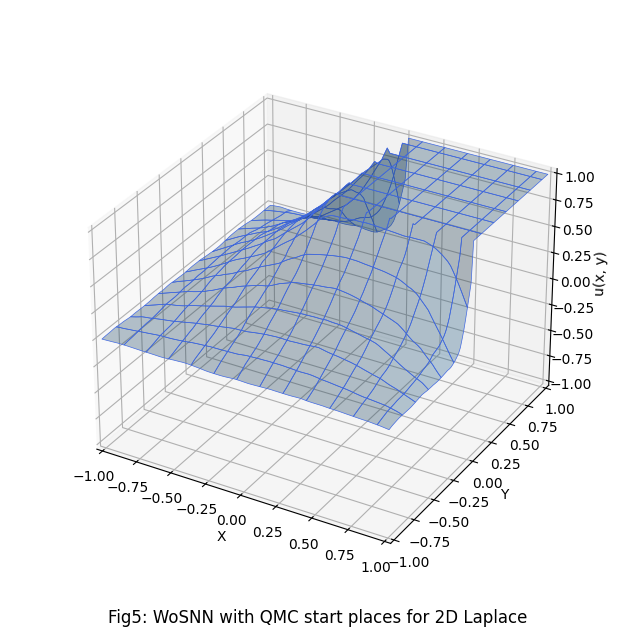

In [109]:
Z1 = X*Y

import matplotlib.pyplot as plt
ax = plt.figure(figsize = (8, 8)).add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Z2, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
#ax.plot_surface(X, Y, Z1, edgecolor='red', lw=0.5, rstride=8, cstride=8,
#                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1),
       xlabel='X', ylabel='Y', zlabel='u(x, y)')

#ax.view_init(30, 90)
ax.set_box_aspect(None, zoom=0.85)
ax.set_title("Fig5: WoSNN with QMC start places for 2D Laplace", y=-0.01)
#plt.show()
plt.savefig('WoSNNqmc2Dlaplace.png', bbox_inches='tight')

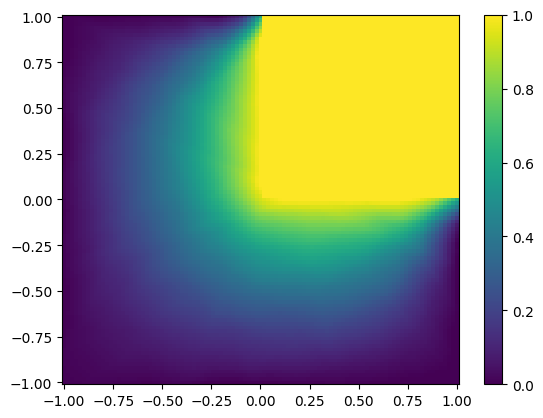

In [131]:
z_min, z_max = -np.abs(Z2).max(), np.abs(Z2).min()
fig, ax = plt.subplots()
c = ax.pcolormesh(X, Y, Z2, cmap = 'viridis', vmin = 0, vmax = 1)
#ax.axis([-1, 1, -1, 1])
fig.colorbar(c, ax = ax)
#plt.show()
plt.savefig('WoSNNLregion.png', bbox_inches='tight')

In [110]:

print("WoSNN mean error for 10000 test points: " + str(np.mean(abs(Z2-Z1))))

WoSNN mean error for 10000 test points: 0.5586847060374648


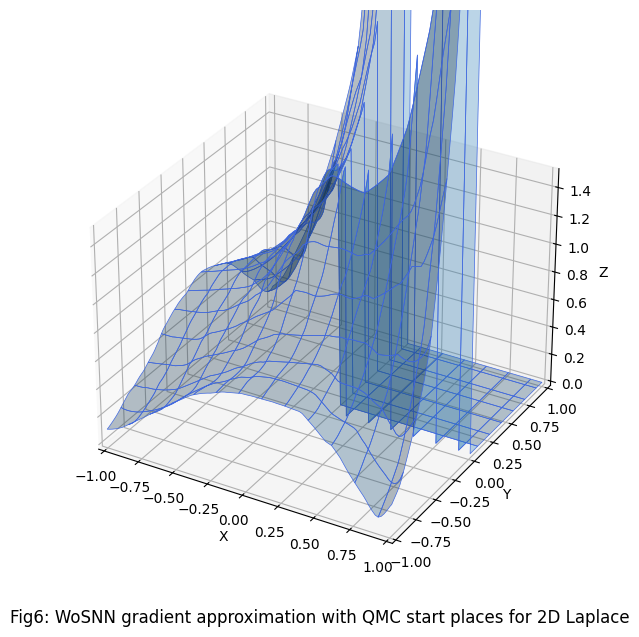

In [111]:
Z3 = np.linalg.norm(np.array(Z)[:, :, 1:3].reshape(-1, 2), axis = 1).reshape(101, 101)
Z1 = np.sqrt(X*X + Y*Y)

import matplotlib.pyplot as plt
ax = plt.figure(figsize = (8, 8)).add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Z3, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
#ax.plot_surface(X, Y, Z1, edgecolor='red', lw=0.5, rstride=8, cstride=8,
#                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(0, 1.5),
       xlabel='X', ylabel='Y', zlabel='Z')

ax.set_box_aspect(None, zoom=0.85)
ax.set_title("Fig6: WoSNN gradient approximation with QMC start places for 2D Laplace", y=-0.01)
#plt.show()
plt.savefig('WoSNN2DqmclaplaceGradient.png', bbox_inches='tight')

In [112]:
print("WoSNN mean gradient error for 10000 test points: " + str(np.mean(abs(Z3-Z1))))

WoSNN mean gradient error for 10000 test points: 0.6866359742991311


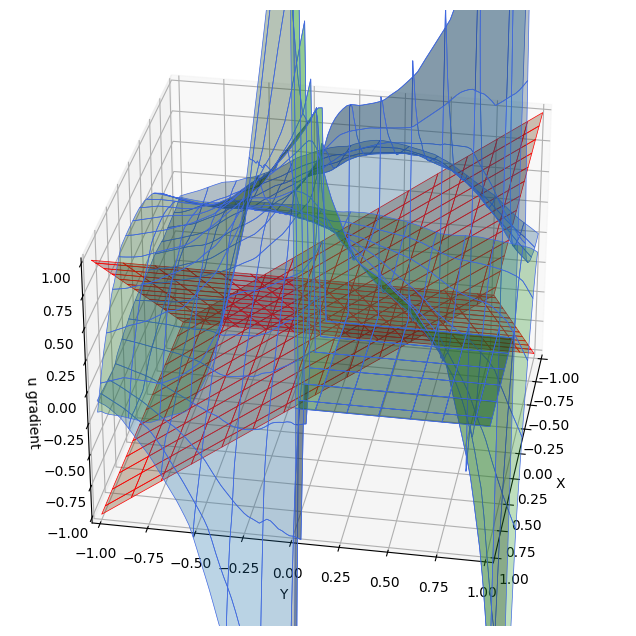

In [113]:
X1 = np.array(Z)[:, :, 1].reshape(101, 101)
X2 = Y
Y1 = np.array(Z)[:, :, 2].reshape(101, 101)
Y2 = X

import matplotlib.pyplot as plt
ax = plt.figure(figsize = (8, 8)).add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, X1, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3, label = 'gradient of x')
ax.plot_surface(X, Y, X2, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, Y1, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3, label = 'gradient of y')
ax.plot_surface(X, Y, Y2, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1),
       xlabel='X', ylabel='Y', zlabel='u gradient')

ax.view_init(30, 10)

#ax.set_box_aspect(None, zoom=0.85)
#ax.set_title("Fig4: WoSNN gradient approximation with evenly distributed start places for 2D Laplace", y=-0.01)
plt.show()
#plt.savefig('WoSNNeven2DlaplaceGradient.png', bbox_inches='tight')

(101, 101)


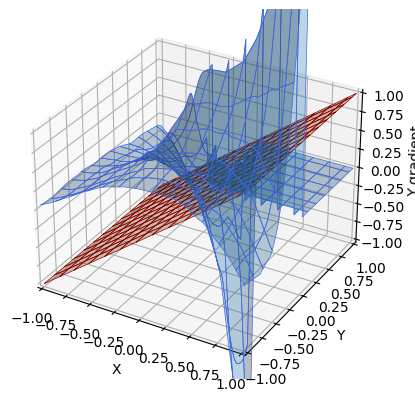

In [114]:
Y1 = np.array(Z)[:, :, 2].reshape(101, 101)
Y2 = X
print(Y1.shape)

import matplotlib.pyplot as plt
ax = plt.figure().add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Y1, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, Y2, edgecolor='darkred', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1),
       xlabel='X', ylabel='Y', zlabel='Y gradient')

plt.show()

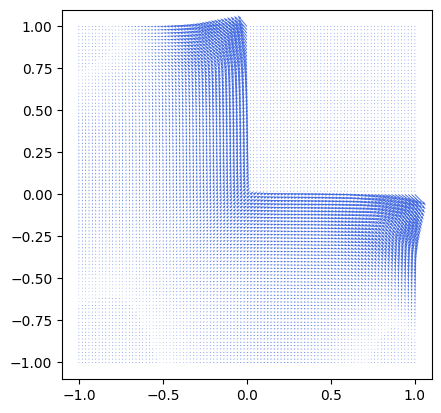

In [115]:
x = np.arange(-1, 1.02, 0.02)
y = np.arange(-1, 1.02, 0.02)
 
# Creating gradient
X, Y = np.meshgrid(x, y)
Z4 = X * Y
dx, dy = np.gradient(Z4)
Z3 = np.array(Z)[:, :, 1:3].reshape(-1, 2)

 
# Creating plot 
fig, ax = plt.subplots()
#ax.quiver(X, Y, dx, dy, color = 'red')
ax.quiver(X, Y, Z3[:, 0].reshape(101, 101), Z3[:, 1].reshape(101, 101), color = 'royalblue')
 
#ax.xaxis.set_ticks([])
#ax.yaxis.set_ticks([])
ax.set_aspect('equal')
 
# show plot
plt.show()

In [116]:
paths1[1]

array([[-2.4313858e-01,  6.2025601e-01],
       [-1.4529584e-03,  6.4679712e-01],
       [-2.8488275e-03,  6.4639384e-01],
       [-1.5849016e-03,  6.4894694e-01],
       [-3.0001153e-03,  6.4823341e-01],
       [-3.1666250e-03,  6.4523792e-01],
       [-2.4675748e-03,  6.4214939e-01],
       [-3.1813115e-03,  6.4451152e-01],
       [-2.7802375e-03,  6.4135557e-01],
       [-5.4374868e-03,  6.4053780e-01],
       [-1.0874787e-02,  6.4058286e-01],
       [-5.1783200e-04,  6.4389867e-01],
       [-5.1783200e-04,  6.4389867e-01],
       [-5.1783200e-04,  6.4389867e-01],
       [-5.1783200e-04,  6.4389867e-01],
       [-5.1783200e-04,  6.4389867e-01],
       [-5.1783200e-04,  6.4389867e-01],
       [-5.1783200e-04,  6.4389867e-01],
       [-5.1783200e-04,  6.4389867e-01],
       [-5.1783200e-04,  6.4389867e-01],
       [-5.1783200e-04,  6.4389867e-01],
       [-5.1783200e-04,  6.4389867e-01],
       [-5.1783200e-04,  6.4389867e-01],
       [-5.1783200e-04,  6.4389867e-01],
       [-5.17832

In [117]:
target

array([[-0.88859195, -0.46086344],
       [-0.24313859,  0.62025601],
       [ 0.61452486, -0.53255717],
       ...,
       [-0.12826242, -0.2646447 ],
       [-0.99049913,  0.65841661],
       [ 0.37107164, -0.74245155]])